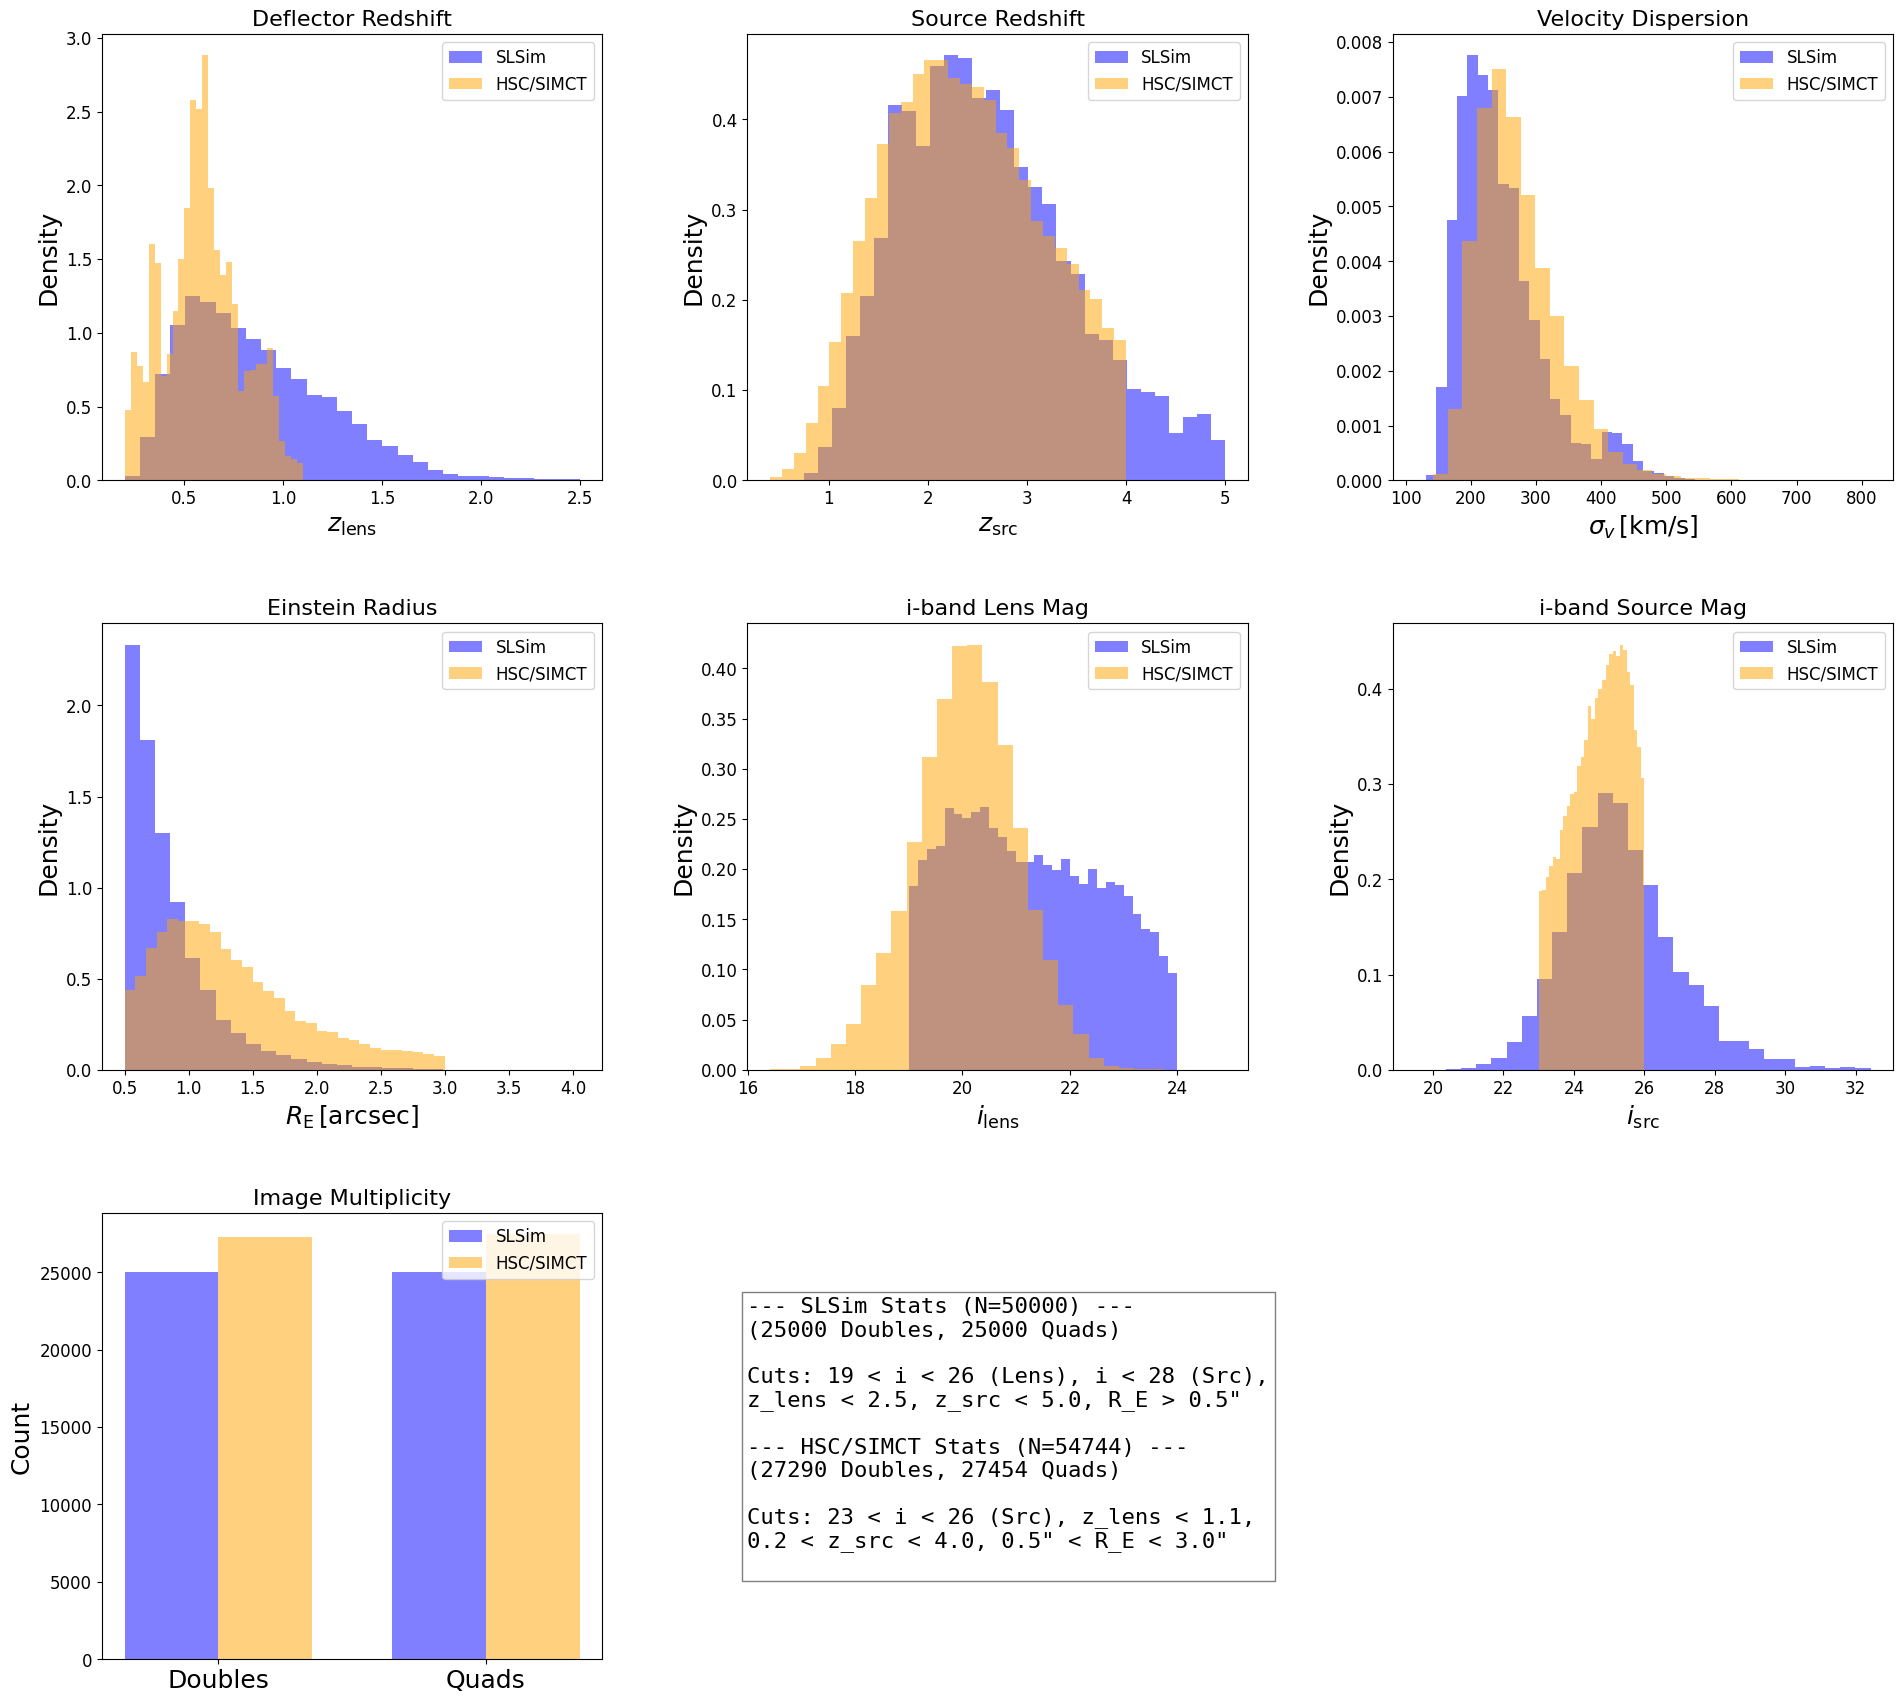

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

# Set global font sizes
plt.rcParams.update({'font.size': 14, 'axes.titlesize': 16, 'axes.labelsize': 14, 'xtick.labelsize': 12, 'ytick.labelsize': 12})

# 1. Load the Tables
# HSC_lagn_table = Table.read('finalpar_udeep.csv', format='csv') # old catalog
HSC_lagn_table = Table.read('merged_finalpar.csv', format='csv') # new catalog
SLSim_lagn_table = Table.read('SLSim_table_lensed_quasars_balanced.fits', format='fits')

# 2. Rename HSC Columns
hsc_mapping = {
    'galaxy_z': 'zlens', 'galaxy_velocity_dispersion': 'vel_disp',
    'galaxy_ellipticity': 'ell_m', 'galaxy_PA': 'ell_m_PA',
    'galaxy_Einstein_radius': 'Rein', 'galaxy_imag': 'mag_lens_i',
    'source_redshift': 'zsrc', 'source_imag': 'mag_src_i',
    'image_count': 'num_images'
}
for hsc_col, slsim_col in hsc_mapping.items():
    if hsc_col in HSC_lagn_table.colnames:
        HSC_lagn_table.rename_column(hsc_col, slsim_col)

# 3. Plotting Configuration
plot_configs = [
    {'col': 'zlens', 'label': 'Deflector Redshift', 'xlabel': '$z_{\\text{lens}}$'},
    {'col': 'zsrc', 'label': 'Source Redshift', 'xlabel': '$z_{\\text{src}}$'},
    {'col': 'vel_disp', 'label': 'Velocity Dispersion', 'xlabel': '$\\sigma_v \\, [\\text{km/s}]$'},
    {'col': 'Rein', 'label': 'Einstein Radius', 'xlabel': '$R_{\\text{E}} \\, [\\text{arcsec}]$'},
    {'col': 'mag_lens_i', 'label': 'i-band Lens Mag', 'xlabel': '$i_{\\text{lens}}$'},
    {'col': 'mag_src_i', 'label': 'i-band Source Mag', 'xlabel': '$i_{\\text{src}}$'}
]

fig, axes = plt.subplots(3, 3, figsize=(20, 18))
axes = axes.flatten()

# Plot histograms
for i, config in enumerate(plot_configs):
    col = config['col']
    axes[i].hist(SLSim_lagn_table[col], bins=30, alpha=0.5, label='SLSim', color='blue', density=True)
    axes[i].hist(HSC_lagn_table[col], bins=30, alpha=0.5, label='HSC/SIMCT', color='orange', density=True)
    axes[i].set_title(config['label'], fontsize=16)
    axes[i].set_xlabel(config['xlabel'], fontsize=18)
    axes[i].set_ylabel('Density', fontsize=18)
    axes[i].legend(fontsize=12)

# Image Multiplicity (6th axis)
ax_mult = axes[6]
slsim_mult, hsc_mult = SLSim_lagn_table['num_images'], HSC_lagn_table['num_images']
labels = ['Doubles', 'Quads']
slsim_counts = [np.sum(slsim_mult == 2), np.sum(slsim_mult == 4)]
hsc_counts = [np.sum(hsc_mult == 2), np.sum(hsc_mult == 4)]

x = np.arange(len(labels))
ax_mult.bar(x - 0.175, slsim_counts, 0.35, label='SLSim', color='blue', alpha=0.5)
ax_mult.bar(x + 0.175, hsc_counts, 0.35, label='HSC/SIMCT', color='orange', alpha=0.5)
ax_mult.set_title('Image Multiplicity', fontsize=16)
ax_mult.set_ylabel('Count', fontsize=18)
ax_mult.set_xticks(x)
ax_mult.set_xticklabels(labels, fontsize=18)
ax_mult.legend(fontsize=12)

# Info Panel (7th axis)
ax_info = axes[7]
ax_info.axis('off')
info_text = (
    f"--- SLSim Stats (N={len(SLSim_lagn_table)}) ---\n"
    f"({len(SLSim_lagn_table[SLSim_lagn_table['num_images'] == 2])} Doubles, {len(SLSim_lagn_table[SLSim_lagn_table['num_images'] == 4])} Quads)\n"
    "\nCuts: 19 < i < 26 (Lens), i < 28 (Src),\n"
    "z_lens < 2.5, z_src < 5.0, R_E > 0.5\"\n\n"
    f"--- HSC/SIMCT Stats (N={len(HSC_lagn_table)}) ---\n"
    f"({len(HSC_lagn_table[HSC_lagn_table['num_images'] == 2])} Doubles, {len(HSC_lagn_table[HSC_lagn_table['num_images'] == 4])} Quads)\n"
    "\nCuts: 23 < i < 26 (Src), z_lens < 1.1,\n"
    "0.2 < z_src < 4.0, 0.5\" < R_E < 3.0\"\n"
)
ax_info.text(0, 0.5, info_text, fontsize=16, va='center', family='monospace', bbox=dict(facecolor='white', alpha=0.5))

axes[8].axis('off')
plt.tight_layout(pad=3.0)
plt.show()